<a href="https://colab.research.google.com/github/AslesaLamsal/AI-and-Machine-Learning/blob/main/Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Getting Started with Image Processing with Python.

Complete all the Task.
1. Read and display the image.

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.

In [ ]:
from PIL import Image

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
image_colored = Image.open("/content/drive/MyDrive/AI and Machine Learning/House.png")

In [ ]:
print("Format:", image_colored.format)
print("Mode:", image_colored.mode)
print("Size:", image_colored.size)

Format: PNG
Mode: P
Size: (1200, 1200)


In [ ]:
image_colored = image_colored.convert("RGB")
print(image_colored.mode)

RGB


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


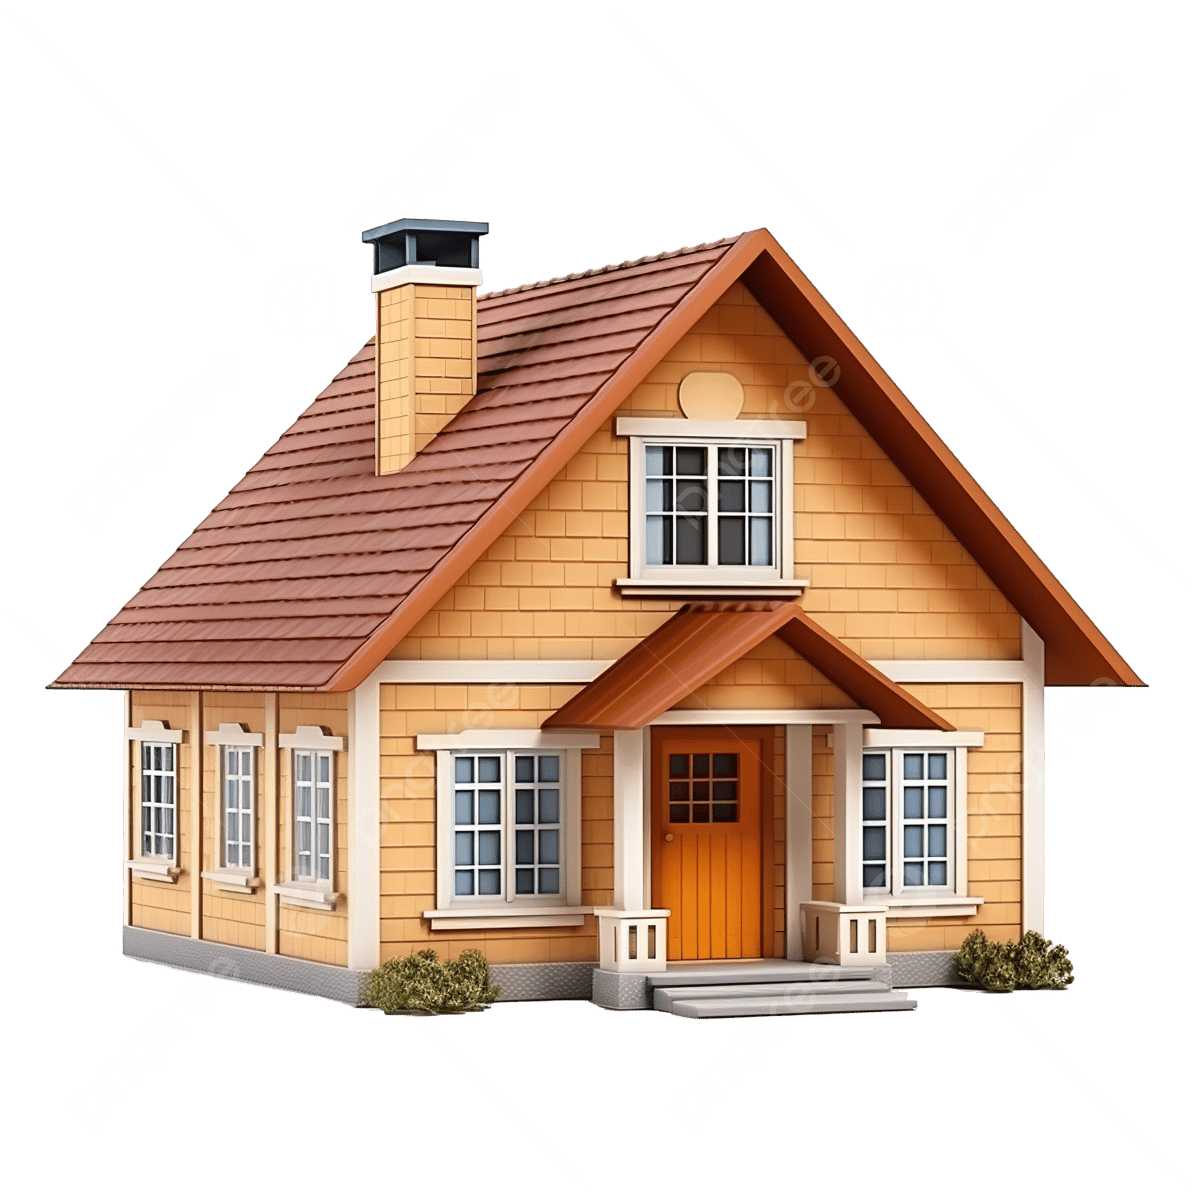

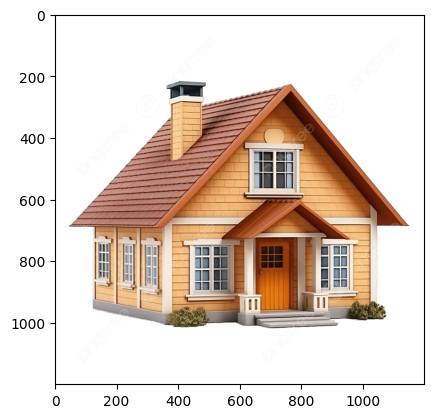

In [ ]:
display(image_colored)
plt.imshow(image_colored)

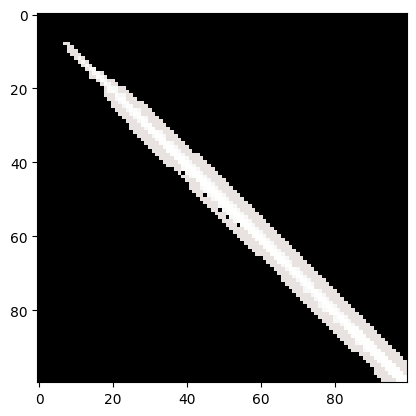

In [ ]:
image_array = np.array(image_colored)
cropped_image = image_array[0:100, 0:100] #upper:lower, left:right
plt.imshow(cropped_image)
plt.show()

In [ ]:
print(image_array.shape)

(1200, 1200, 3)


Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

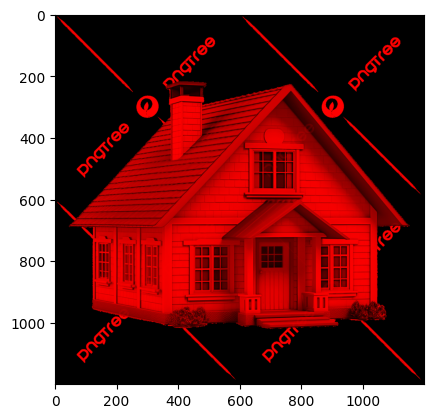

In [ ]:
red_channel = image_array.copy()
red_channel[:, :, 1] = 0
red_channel[:, :, 2] = 0
plt.imshow(red_channel)


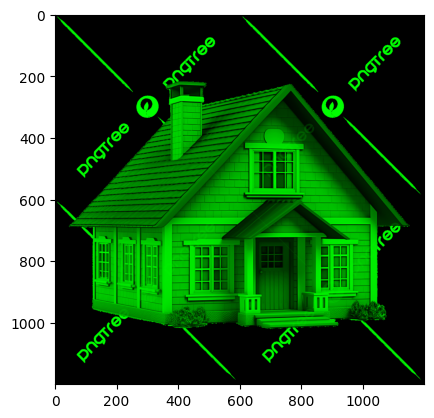

In [ ]:
green_channel = image_array.copy()
green_channel[:, :, 0] = 0
green_channel[:, :, 2] = 0
plt.imshow(green_channel)

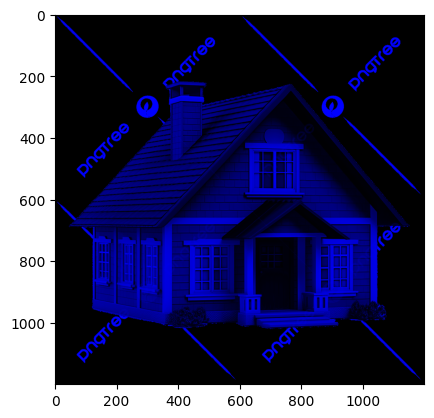

In [ ]:
blue_channel = image_array.copy()
blue_channel[:, :, 0] = 0
blue_channel[:, :, 1] = 0
plt.imshow(blue_channel)

Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

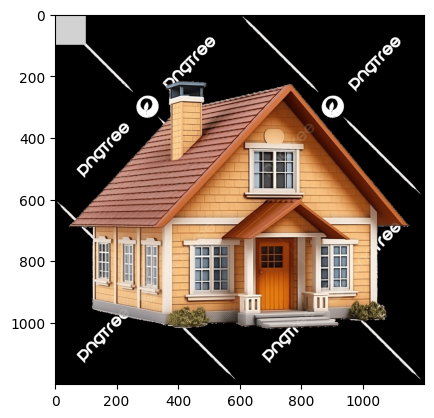

In [ ]:
modified_image = image_array.copy()
modified_image[0:100, 0:100] = 210
plt.imshow(modified_image)

**Exercise - 2:**

**1. Load and display a grayscale image.**

**• Load a grayscale image using the Pillow library.**


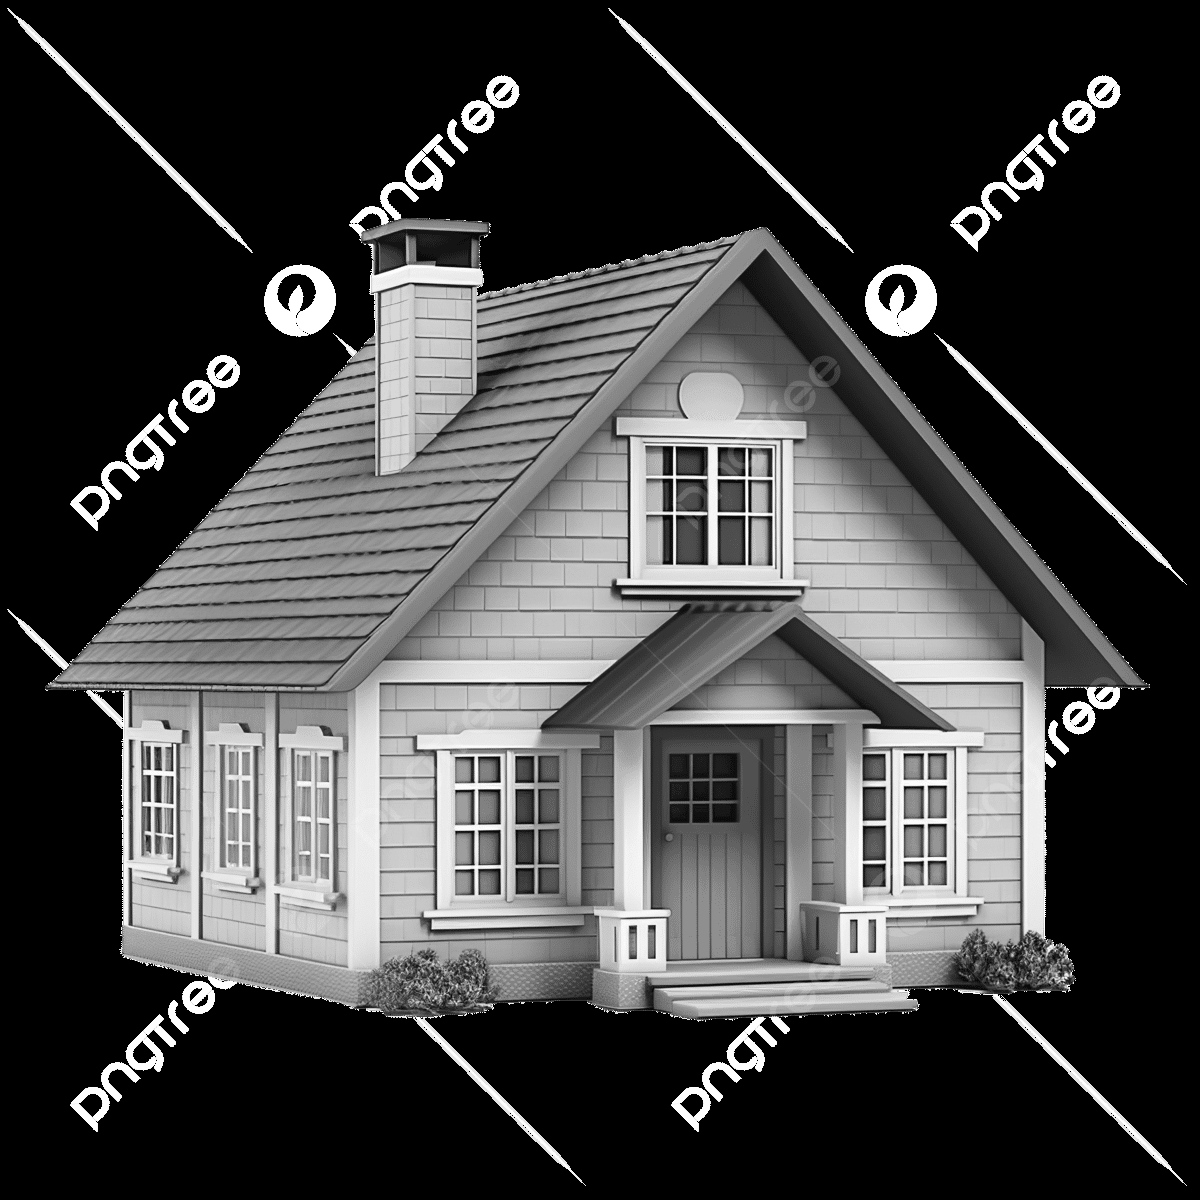

In [ ]:
image_grayed = image_colored.convert("L")
display(image_grayed)

**• Display the grayscale image using matplotlib.**

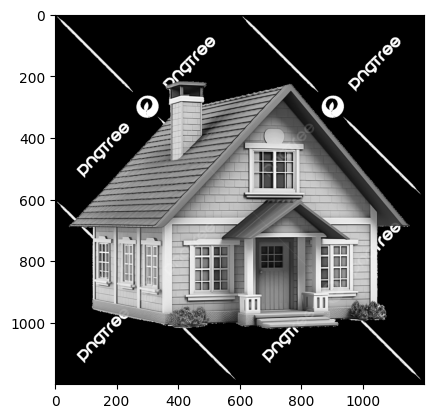

In [ ]:
plt.imshow(image_grayed, cmap='gray')

**2. Extract and display the middle section of the image (150 pixels).**

**• Extract a 150 pixel section from the center of the image using NumPy array slicing.**

In [ ]:
image_array = np.array(image_grayed)
h, w = image_array.shape
center_image = image_array[h//2-75:h//2+75, w//2-75:w//2+75] #[row, column]


**• Display this cropped image using matplotlib.**

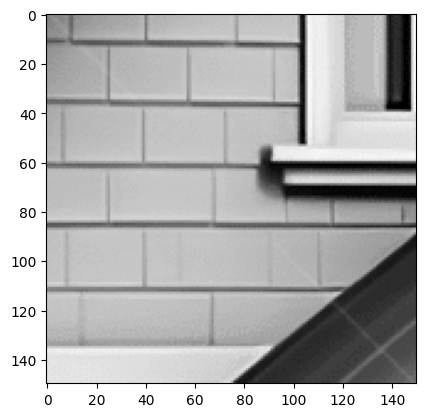

In [ ]:
plt.imshow(center_image, cmap='gray')

**3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).**

**• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values above 100 to 255 (creating a binary image).**

In [ ]:
binary_image = image_array.copy()
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255

**• Display the resulting binary image.**

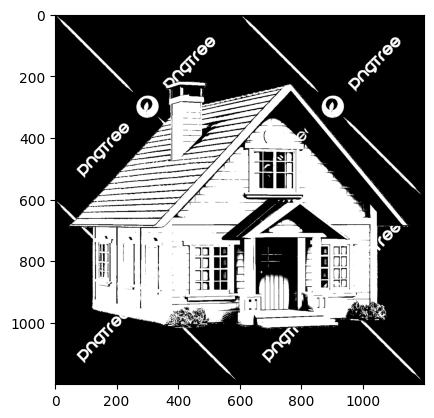

In [ ]:
plt.imshow(binary_image, cmap='gray')

**4. Rotate the image 90 degrees clockwise and display the result.**

**• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.**

In [ ]:
rotated_image = image_grayed.rotate(-90, expand=True)

**• Display the rotated image using matplotlib.**

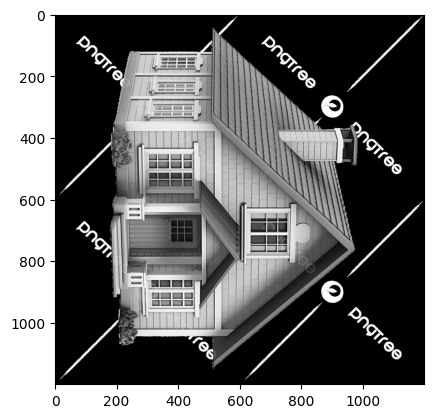

In [ ]:
plt.imshow(rotated_image, cmap='gray')

**5. Convert the grayscale image to an RGB image.**

**• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).**

In [ ]:
rgb_image = np.stack((image_array,)*3, axis=-1)

**• Display the converted RGB image using matplotlib.**

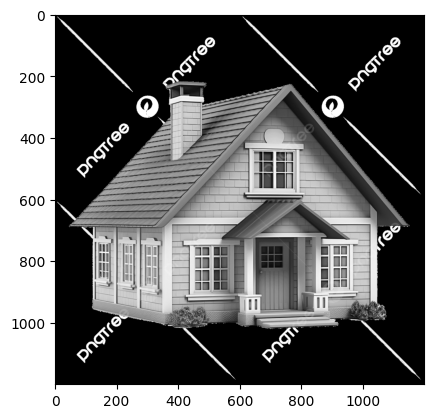

In [ ]:
plt.imshow(rgb_image)

**3 Image Compression and Decompression using PCA.**

**1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}**

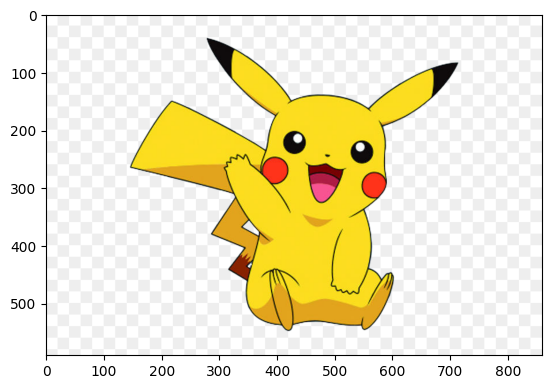

In [ ]:
colored_image = Image.open("/content/drive/MyDrive/AI and Machine Learning/Pokemon.png")
plt.imshow(colored_image)

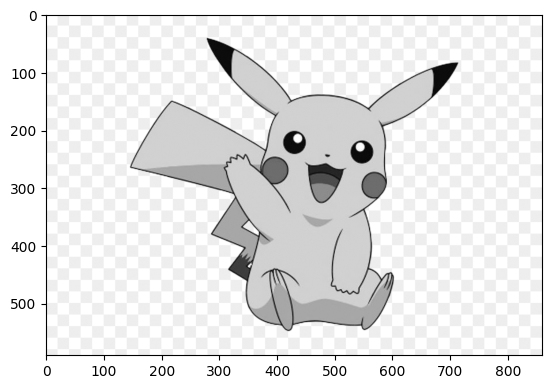

In [ ]:
image_grayed = colored_image.convert("L")
plt.imshow(image_grayed, cmap='gray')

In [ ]:
array_numpy = np.array(image_grayed, dtype=float)
print(array_numpy.shape)

(590, 860)


**• Center the dataset - Standaridze the Data.**

In [ ]:
centered_dataset = array_numpy - np.mean(array_numpy, axis=0)

**• Calculate the covaraince matrix of the Standaridze data.**

In [ ]:
cov_matrix = np.cov(centered_dataset, rowvar=False)
print(cov_matrix.shape)

(860, 860)


**2. Eigen Decomposition and Identifying Principal Components:**

**• Compute Eigen Values and Eigen Vectors.**

In [ ]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues shape:", eigen_values.shape)
print("Eigenvectors shape:", eigen_vectors.shape)

Eigenvalues shape: (860,)
Eigenvectors shape: (860, 860)


**• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to the highest eigenvalues.**


In [ ]:
sorted_indices = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]

**• Identify the Principal Components with the help of cumulative Sum plot.**

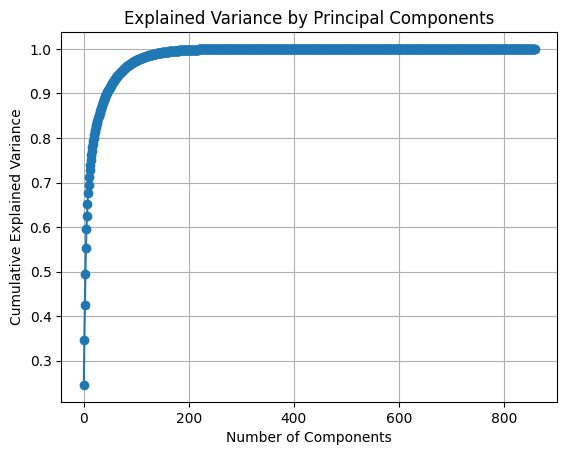

In [ ]:
explained_variance = eigen_values / np.sum(eigen_values)
cumulative_variance = np.cumsum(explained_variance)
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.grid(True)
plt.show()

In [ ]:
k = 50
top_k_eigvecs = eigen_vectors[:, :k]

In [ ]:
X_compressed = np.dot(centered_dataset, top_k_eigvecs)

In [ ]:
X_reconstructed = np.dot(X_compressed, top_k_eigvecs.T) + np.mean(array_numpy, axis=0)

In [ ]:
k_values = [10, 20, 50, 100, 150]
reconstructed_images = []

for k in k_values:
    top_k_eigvecs = eigen_vectors[:, :k]
    X_compressed = np.dot(centered_dataset, top_k_eigvecs)
    X_reconstructed = np.dot(X_compressed, top_k_eigvecs.T) + np.mean(array_numpy, axis=0)
    reconstructed_images.append(X_reconstructed)

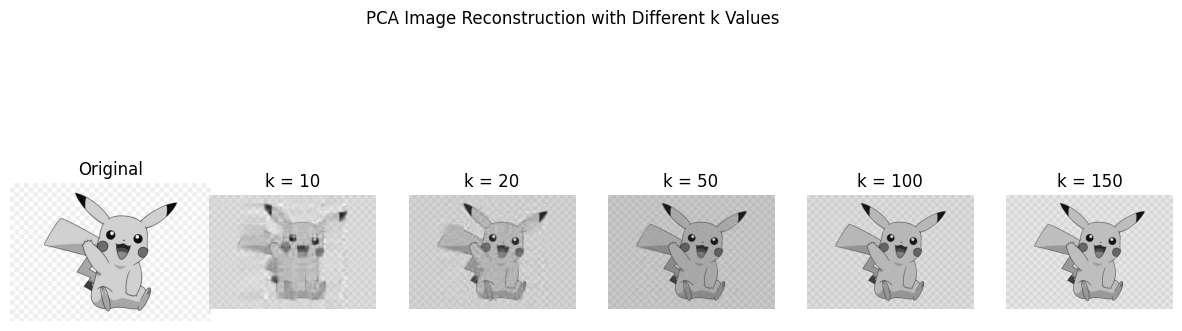

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1, 5, 1)
plt.imshow(array_numpy, cmap='gray')
plt.title("Original")
plt.axis('off')
for i, X_rec in enumerate(reconstructed_images):
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(X_rec, cmap='gray')
    plt.title(f"k = {k_values[i]}")
    plt.axis('off')

plt.suptitle("PCA Image Reconstruction with Different k Values")
plt.show()